In [44]:
# In[1]

import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from datetime import datetime

sns.set_theme(style='whitegrid')

# Adjust display options if desired
pd.options.display.max_rows = 50
pd.options.display.max_columns = 20


In [45]:
# In[2]

# 2.1 Load the JSON
with open('github-data.json', 'r', encoding='utf-8') as f:
    data = json.load(f)

members = data['members']           # List of member dicts
repositories = data['repositories'] # List of repo dicts
issues_by_repo = data['issues']     # { repo_name: [issues], ... }
issues_events_by_repo = data['issues_events'] # { repo_name: [issue_events], ... }
commits_by_repo = data['commits']   # { repo_name: [commits], ... }
timeline_events_by_repo = data['timeline_events']    # List of event dicts
relationship_mapping_by_repo = data['relationship_mapping'] # List of relationship dicts

# 2.2 Convert members to a DataFrame
df_members = pd.DataFrame(members)

# 2.3 Quick inspection
display(df_members.head())


,id,node_id,login,public_repos,followers,following,created_at,active
0,108633030,U_kgDOBnmbxg,Adleey,2,0,0,2022-07-03T21:05:41Z,True
1,134176815,U_kgDOB_9gLw,AugustoLiberato,11,4,8,2023-05-20T23:51:44Z,True
2,95926022,U_kgDOBbe3Bg,Benjamin-Nobrega,6,2,3,2021-12-10T14:58:06Z,True
3,12025215,MDQ6VXNlcjEyMDI1MjE1,danrleypereira,51,42,33,2015-04-20T00:48:52Z,True
4,49729245,MDQ6VXNlcjQ5NzI5MjQ1,devmarcosvinicius,17,55,44,2019-04-17T17:31:01Z,True


In [46]:
# In[3]

def parse_github_date(date_str):
    # e.g. '2022-07-03T21:05:41Z'
    return datetime.strptime(date_str, '%Y-%m-%dT%H:%M:%SZ')

now = datetime.now()

# Compute account age (days) from created_at
df_members['account_age_days'] = df_members['created_at'].apply(
    lambda d: (now - parse_github_date(d)).days
)

# Define a maturity score TODO: Adjust weights
# Podemos manter a idade da conta com um peso moderado
age_component = 0.5 * np.log1p(df_members['account_age_days'])

# Usamos log para os repositórios, com um peso menor, já que forks podem inflacionar esse valor
public_repos_component = 3 * np.log1p(df_members['public_repos'])

# Seguidores, que são mais difíceis de conseguir, recebem um peso maior
followers_component = 20 * np.log1p(df_members['followers'])

df_members['maturity_score'] = age_component + public_repos_component + followers_component

# Classify new vs. established
df_members['status'] = df_members.apply(
    lambda row: 'new' if (
        row['account_age_days'] < 365
        or (row['public_repos'] < 10
        and row['followers'] < 10)
    ) else 'established',
    axis=1
)

df_members.head()


,id,node_id,login,public_repos,followers,following,created_at,active,account_age_days,maturity_score,status
0,108633030,U_kgDOBnmbxg,Adleey,2,0,0,2022-07-03T21:05:41Z,True,957,6.728261,new
1,134176815,U_kgDOB_9gLw,AugustoLiberato,11,4,8,2023-05-20T23:51:44Z,True,636,42.871863,established
2,95926022,U_kgDOBbe3Bg,Benjamin-Nobrega,6,2,3,2021-12-10T14:58:06Z,True,1162,31.339355,new
3,12025215,MDQ6VXNlcjEyMDI1MjE1,danrleypereira,51,42,33,2015-04-20T00:48:52Z,True,3589,91.170687,established
4,49729245,MDQ6VXNlcjQ5NzI5MjQ1,devmarcosvinicius,17,55,44,2019-04-17T17:31:01Z,True,2130,93.010322,established


In [47]:
# In[4]

all_issues = []

for repo_name, issues_list in issues_by_repo.items():
    for issue in issues_list:
        issue_dict = {
            'repo': repo_name,
            'issue_number': issue['number'],
            'title': issue['title'],
            'state': issue['state'],
            'creator': issue['user']['login'],
            'assignee': issue['assignee']['login'] if issue['assignee'] is not None else None,
            'created_at': issue['created_at'],
            'updated_at': issue['updated_at'],
            'pull_request': (issue['pull_request'] is not None),
            'timeline_url': issue.get('timeline_url', None),
        }
        all_issues.append(issue_dict)

df_issues = pd.DataFrame(all_issues)
display(df_issues.head())


,repo,issue_number,title,state,creator,assignee,created_at,updated_at,pull_request,timeline_url
0,python-services,30,[Get] - Todos as Salas Disponíveis em um certo...,open,GuiMcs00,None,2024-12-21T01:14:40Z,2024-12-21T01:14:40Z,False,https://api.github.com/repos/LabTechUDF/python...
1,python-services,29,Processar Ofertas e Salvar na Coleção de Reservas,open,GuiMcs00,None,2024-12-19T18:08:57Z,2024-12-19T18:08:57Z,False,https://api.github.com/repos/LabTechUDF/python...
2,python-services,27,bugfix: send link is not using auth service,open,danrleypereira,josue-oliveiraa,2024-11-22T17:25:04Z,2024-12-04T20:02:40Z,False,https://api.github.com/repos/LabTechUDF/python...
3,python-services,23,22-requisição-aos-recursos-compartilhados,open,Gabriel-br07,Gabriel-br07,2024-11-04T14:56:30Z,2024-12-26T01:14:40Z,True,https://api.github.com/repos/LabTechUDF/python...
4,python-services,22,Requisição aos Recursos Compartilhados,open,GuiMcs00,Gabriel-br07,2024-10-29T00:28:15Z,2024-12-12T18:28:49Z,False,https://api.github.com/repos/LabTechUDF/python...


In [48]:
# In[4.5]

# 4.5.1 Extract issue events
all_issue_events = []
for repo_name, events_list in issues_events_by_repo.items():
    for event in events_list:
        event_dict = {
            'repo': repo_name,
            'issue_number': event['issue']['number'],
            'actor': event['actor']['login'],
            'event': event['event'],
            'created_at': event['created_at'],
        }
        all_issue_events.append(event_dict)

df_issue_events = pd.DataFrame(all_issue_events)
display(df_issue_events.head())
display(df_issue_events['event'].value_counts())

,repo,issue_number,actor,event,created_at
0,python-services,23,Gabriel-br07,review_requested,2024-12-26T01:14:40Z
1,python-services,29,GuiMcs00,labeled,2024-12-19T18:08:57Z
2,python-services,23,Gabriel-br07,review_requested,2024-12-13T19:18:58Z
3,python-services,28,danrleypereira,closed,2024-12-08T04:28:15Z
4,python-services,28,danrleypereira,merged,2024-12-08T04:28:15Z


event
assigned                  56
closed                    53
review_requested          38
merged                    33
referenced                31
connected                 22
head_ref_deleted          22
renamed                   18
labeled                   17
unassigned                10
subscribed                 4
mentioned                  4
base_ref_changed           3
head_ref_force_pushed      2
disconnected               2
head_ref_restored          1
review_request_removed     1
Name: count, dtype: int64

In [49]:
all_commits = []

for repo_name, commits_list in commits_by_repo.items():
    for commit in commits_list:
        commit_dict = {
            'repo': repo_name,
            'sha': commit['sha'],
            'author': commit['author']['login'] if commit['author'] is not None else None,
            'message': commit['commit']['message'],
            'created_at': commit['commit']['author']['date'],
        }
        all_commits.append(commit_dict)

df_commits = pd.DataFrame(all_commits)
display(df_commits.head())
display(df_commits['author'].value_counts())

,repo,sha,author,message,created_at
0,python-services,88509b5afd7edcc92c55b0b691f366a6a0b04a86,polyanacunha,refactor(send-link): Token insertion correctly...,2024-12-08T06:38:39Z
1,python-services,1601fcef7188a3dcd8fb7b80bb8e557e216e68cf,danrleypereira,fix: validate authentication endpoint (#28)\n\...,2024-12-08T04:28:15Z
2,python-services,cb6c5803c71e9238b3796946f217ec4b511cae58,josue-oliveiraa,Merge pull request #25 from LabTechUDF/refacto...,2024-12-03T23:48:46Z
3,python-services,d29b9ebbca9a8f5907ac0d8ffa2e347eade4f155,josue-oliveiraa,Merge branch 'main' into refactor/arquitetura-...,2024-12-03T23:47:56Z
4,python-services,9707b32dc1c4ba0fa54be7e7d48ebbcbef0ba5b4,josue-oliveiraa,Realocação do método de craição do Hash para a...,2024-11-17T22:31:42Z


author
tauisilva           83
danrleypereira      48
GuiMcs00            21
polyanacunha        17
thiagodiasz         16
duduzgomes          10
Lucas-Germano        9
YuriNoriki           8
josue-oliveiraa      7
juanpbarros20        7
AugustoLiberato      6
Gabriel-br07         5
Bnicole98            5
mysterious-man01     5
Benjamin-Nobrega     3
whiterabbitholes     3
MartinsArtur         2
eduardasf            1
raypaivac123         1
Name: count, dtype: int64

In [50]:
# In[5]

all_timeline_events = []

for repo_name, issues in timeline_events_by_repo.items():
    for issue_number, events in issues.items():
        for evt in events:
            # Extract the created_at timestamp based on event type
            if evt.get("event") == "committed":
                # For commit events, try to get the timestamp from author or committer
                created_at = evt.get("author", {}).get("date") or evt.get("committer", {}).get("date")
            elif evt.get("event") == "reviewed":
                # For review events, use 'submitted_at' if available
                created_at = evt.get("submitted_at")
            else:
                created_at = evt.get("created_at")
            
            # Extract the actor's login. Some events use "actor", others might use "user"
            actor = evt.get("actor", {}).get("login") or evt.get("user", {}).get("login", "")
            
            all_timeline_events.append({
                'repo': repo_name,
                'issue_number': issue_number,
                'event': evt.get('event', ''),
                'created_at': created_at,
                'actor': actor
            })

# Create the dataframe from the normalized list of events
df_timeline = pd.DataFrame(all_timeline_events)
display(df_timeline.head())
display(df_timeline['event'].value_counts())
display(df_timeline['event'].unique())
display(df_timeline['repo'].unique())



,repo,issue_number,event,created_at,actor
0,python-services,29,labeled,2024-12-19T18:08:57Z,GuiMcs00
1,python-services,27,assigned,2024-11-22T17:25:04Z,danrleypereira
2,python-services,27,commented,2024-12-04T00:22:35Z,josue-oliveiraa
3,python-services,27,commented,2024-12-04T00:25:02Z,josue-oliveiraa
4,python-services,23,committed,2024-11-04T14:53:42Z,


event
committed                 87
assigned                  13
labeled                   11
review_requested           9
commented                  8
connected                  6
reviewed                   5
renamed                    3
subscribed                 2
mentioned                  2
unassigned                 1
cross-referenced           1
review_request_removed     1
Name: count, dtype: int64

array(['labeled', 'assigned', 'commented', 'committed', 'connected',
       'review_requested', 'reviewed', 'unassigned', 'renamed',
       'review_request_removed', 'cross-referenced', 'mentioned',
       'subscribed'], dtype=object)

array(['python-services', 'interfaces-usuario', 'teachers-allocation',
       'research', 'shared-resources'], dtype=object)

In [51]:
# In[6]

# We'll define "contributions" = #issues created + #issues assigned + #PRs authored + #commits + #PRs reviewed + #comments
contributions_per_user = {}

for repo_name, issues_list in issues_by_repo.items():
    for issue_data in issues_list:
        creator = issue_data['user']['login']
        assignee = issue_data['assignee']['login'] if issue_data['assignee'] is not None else None
        if creator not in contributions_per_user:
            contributions_per_user[creator] = {'issues-created': 0, 'issues-assigned': 0, 'commits': 0, 'prs-authored': 0, 'prs-reviewed': 0, 'comments': 0 }
        if assignee is not None and assignee not in contributions_per_user:
            contributions_per_user[assignee] = {'issues-created': 0, 'issues-assigned': 0, 'commits': 0, 'prs-authored': 0, 'prs-reviewed': 0, 'comments': 0 }
        if issue_data['pull_request'] is not None:
            contributions_per_user[creator]['prs-authored'] += 1
        elif assignee is not None and creator != assignee:
            contributions_per_user[creator]['issues-created'] += 1
            contributions_per_user[assignee]['issues-assigned'] += 1
        else:
            contributions_per_user[creator]['issues-created'] += 1

df_members['issues-created'] = df_members['login'].apply(
    lambda login: contributions_per_user.get(login, {}).get('issues-created', 0)
)
df_members['issues-assigned'] = df_members['login'].apply(
    lambda login: contributions_per_user.get(login, {}).get('issues-assigned', 0)
)
df_members['prs-authored'] = df_members['login'].apply(
    lambda login: contributions_per_user.get(login, {}).get('prs-authored', 0)
)

df_members.head()


,id,node_id,login,public_repos,followers,following,created_at,active,account_age_days,maturity_score,status,issues-created,issues-assigned,prs-authored
0,108633030,U_kgDOBnmbxg,Adleey,2,0,0,2022-07-03T21:05:41Z,True,957,6.728261,new,0,0,0
1,134176815,U_kgDOB_9gLw,AugustoLiberato,11,4,8,2023-05-20T23:51:44Z,True,636,42.871863,established,0,0,0
2,95926022,U_kgDOBbe3Bg,Benjamin-Nobrega,6,2,3,2021-12-10T14:58:06Z,True,1162,31.339355,new,0,0,0
3,12025215,MDQ6VXNlcjEyMDI1MjE1,danrleypereira,51,42,33,2015-04-20T00:48:52Z,True,3589,91.170687,established,9,1,3
4,49729245,MDQ6VXNlcjQ5NzI5MjQ1,devmarcosvinicius,17,55,44,2019-04-17T17:31:01Z,True,2130,93.010322,established,0,0,0


In [52]:
# # In[6.0.1]

# # 6.0.2 Extract review events
# all_reviews = df_issue_events[df_issue_events['event'] == 'reviewed']
# # get the count of reviews per user
# reviews_per_user = all_reviews['actor'].value_counts().to_dict()
# # add the count of reviews to the members dataframe
# df_members['prs-reviewed'] = df_members['login'].apply(lambda login: reviews_per_user.get(login, 0))

# df_members.head()

In [53]:
# [6.1]

# create a array of all commits
# df_commits = pd.DataFrame([commit for commits in commits_by_repo.values() for commit in commits])
# get the number of commits per user
commits_per_user = df_commits['author'].apply(lambda x: x['login'] if isinstance(x, dict) else x).value_counts().to_dict()
# add the number of commits to the df_members
df_members['commits'] = df_members['login'].apply(lambda login: commits_per_user.get(login, 0))

# create a array to reviewed events
reviews = df_timeline[df_timeline['event'] == 'reviewed']
# get the number of reviews per user
reviews_per_user = reviews['actor'].value_counts().to_dict()
# add the number of reviews to the df_members
df_members['prs-reviewed'] = df_members['login'].apply(lambda login: reviews_per_user.get(login, 0))

# create a array to commented events
comments = df_timeline[df_timeline['event'] == 'commented']
# get the number of comments per user
comments_per_user = comments['actor'].value_counts().to_dict()
# add the number of comments to the df_members
df_members['comments'] = df_members['login'].apply(lambda login: comments_per_user.get(login, 0))


df_members['total_contribs'] = df_members['issues-created'] + df_members['issues-assigned'] + df_members['commits'] + df_members['prs-authored'] + df_members['prs-reviewed'] + df_members['comments']
df_members['has_contributed'] = df_members['total_contribs'] > 0

df_members.head()

,id,node_id,login,public_repos,followers,following,created_at,active,account_age_days,maturity_score,status,issues-created,issues-assigned,prs-authored,commits,prs-reviewed,comments,total_contribs,has_contributed
0,108633030,U_kgDOBnmbxg,Adleey,2,0,0,2022-07-03T21:05:41Z,True,957,6.728261,new,0,0,0,0,0,0,0,False
1,134176815,U_kgDOB_9gLw,AugustoLiberato,11,4,8,2023-05-20T23:51:44Z,True,636,42.871863,established,0,0,0,6,0,0,6,True
2,95926022,U_kgDOBbe3Bg,Benjamin-Nobrega,6,2,3,2021-12-10T14:58:06Z,True,1162,31.339355,new,0,0,0,3,0,0,3,True
3,12025215,MDQ6VXNlcjEyMDI1MjE1,danrleypereira,51,42,33,2015-04-20T00:48:52Z,True,3589,91.170687,established,9,1,3,48,1,2,64,True
4,49729245,MDQ6VXNlcjQ5NzI5MjQ1,devmarcosvinicius,17,55,44,2019-04-17T17:31:01Z,True,2130,93.010322,established,0,0,0,0,0,0,0,False


In [54]:
import os

def save_plot(fig, file_name, folder_path="graficos"):
    """
    Save the given plot to the specified folder with the given file name.

    Parameters:
    fig (matplotlib.figure.Figure): The figure object to save.
    folder_path (str): The path to the folder where the plot should be saved.
    file_name (str): The name of the file to save the plot as.
    """
    # Create the folder if it doesn't exist
    if not os.path.exists(folder_path):
        os.makedirs(folder_path)
    
    # Construct the full file path
    file_path = os.path.join(folder_path, file_name)
    
    # Save the figure
    fig.savefig(file_path)
    print(f"Plot saved to {file_path}")

# Example usage:
# fig, ax = plt.subplots()
# ax.plot([1, 2, 3], [4, 5, 6])
# save_plot(fig, 'plots', 'example_plot.png')

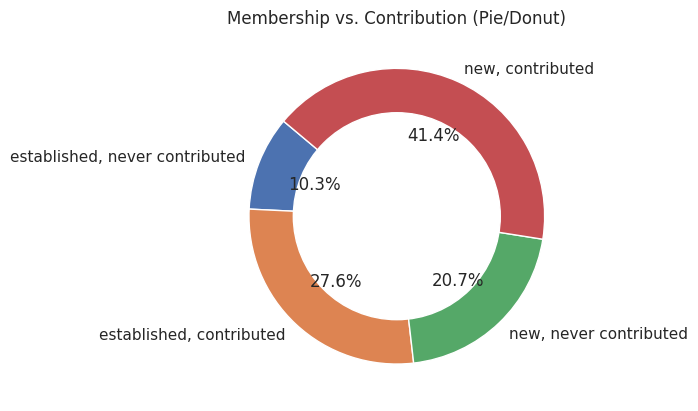

Plot saved to graficos/pie-contributions.png


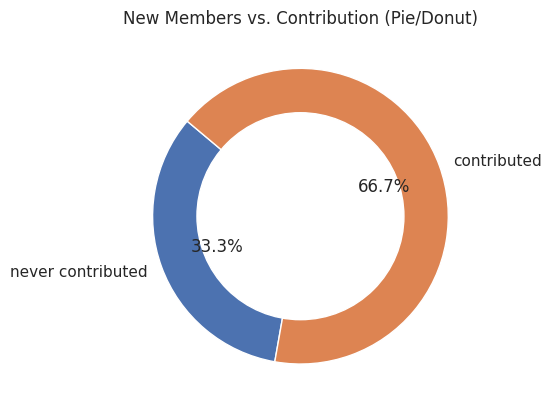

Plot saved to graficos/new-pie-contribution.png


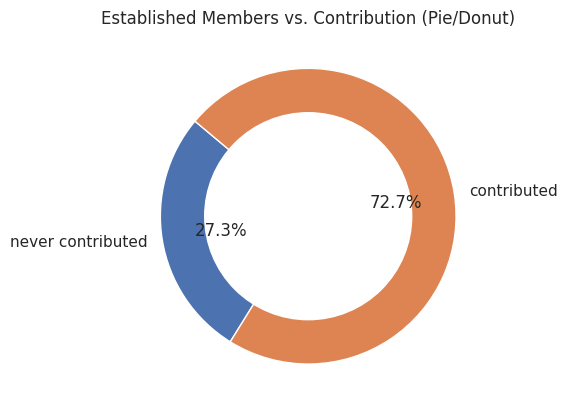

Plot saved to graficos/established-contributions.png


In [55]:
# In[7]

contrib_groups = df_members.groupby(['status', 'has_contributed']).size().reset_index(name='count')

labels = []
sizes = []
for row in contrib_groups.itertuples():
    s = row.status
    c = 'contributed' if row.has_contributed else 'never contributed'
    labels.append(f"{s}, {c}")
    sizes.append(row.count)

fig, ax = plt.subplots()
ax.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=140)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)
plt.title('Membership vs. Contribution (Pie/Donut)')
plt.show()
save_plot(fig, 'pie-contributions.png')

new_members = df_members[df_members['status'] == 'new']
new_contrib_groups = new_members.groupby(['has_contributed']).size().reset_index(name='count')

new_labels = ['contributed' if row.has_contributed else 'never contributed' for row in new_contrib_groups.itertuples()]
new_sizes = new_contrib_groups['count'].tolist()

fig, ax = plt.subplots()
ax.pie(new_sizes, labels=new_labels, autopct='%1.1f%%', startangle=140)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)
plt.title('New Members vs. Contribution (Pie/Donut)')
plt.show()
save_plot(fig, 'new-pie-contribution.png')

# New code for "established" members
established_members = df_members[df_members['status'] == 'established']
established_contrib_groups = established_members.groupby(['has_contributed']).size().reset_index(name='count')

established_labels = ['contributed' if row.has_contributed else 'never contributed' for row in established_contrib_groups.itertuples()]
established_sizes = established_contrib_groups['count'].tolist()

fig, ax = plt.subplots()
ax.pie(established_sizes, labels=established_labels, autopct='%1.1f%%', startangle=140)
centre_circle = plt.Circle((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)
plt.title('Established Members vs. Contribution (Pie/Donut)')
plt.show()
save_plot(fig, 'established-contributions.png')


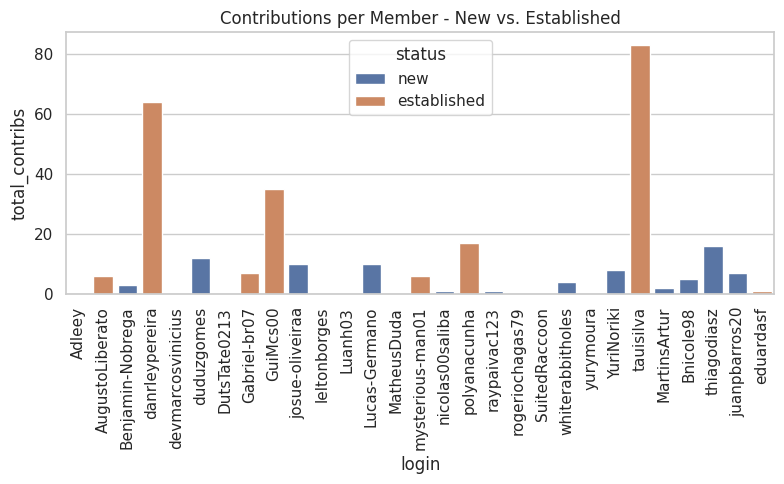

Plot saved to graficos/contributions-per-member.png


In [56]:
# In[8]

fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(data=df_members, x='login', y='total_contribs', hue='status', dodge=False)
plt.xticks(rotation=90)
plt.title('Contributions per Member - New vs. Established')
plt.tight_layout()
plt.show()
save_plot(fig, 'contributions-per-member.png')


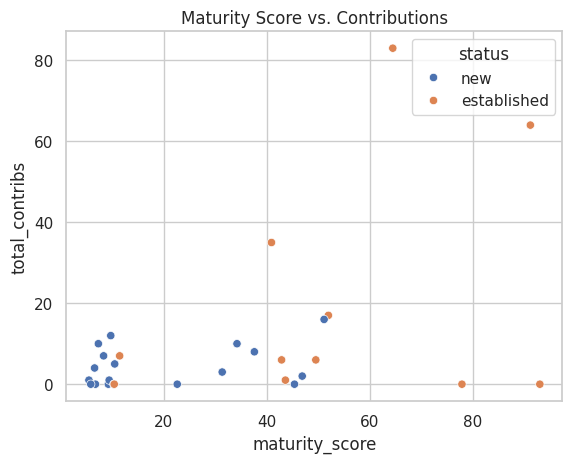

Plot saved to graficos/maturity-vs-contributions.png


In [57]:
# In[9]

fig, ax = plt.subplots()
sns.scatterplot(data=df_members, x='maturity_score', y='total_contribs', hue='status')
plt.title('Maturity Score vs. Contributions')
plt.show()
save_plot(fig, 'maturity-vs-contributions.png')


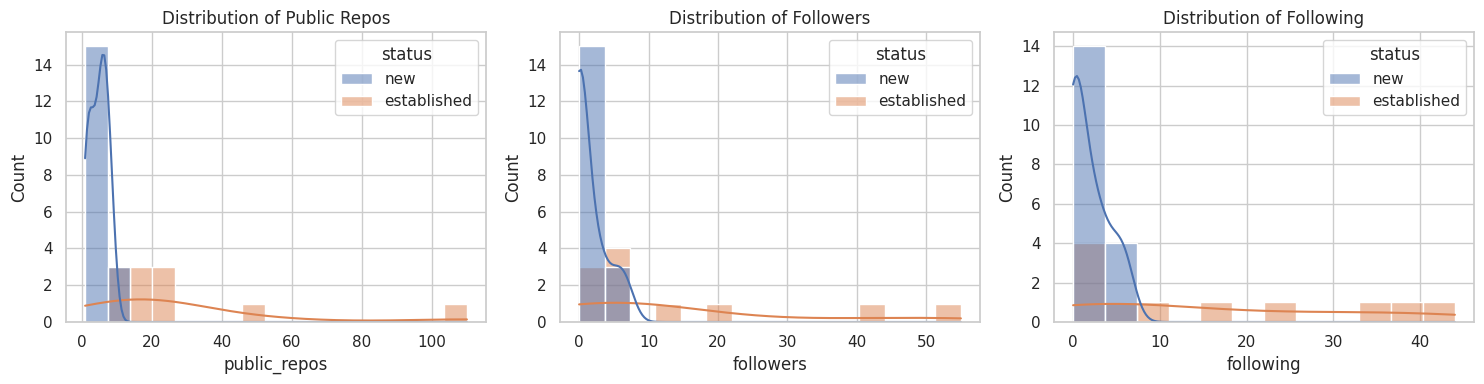

Plot saved to graficos/repos-followers.png


In [58]:
# In[10]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.histplot(data=df_members, x='public_repos', hue='status', kde=True, ax=axes[0])
axes[0].set_title('Distribution of Public Repos')

sns.histplot(data=df_members, x='followers', hue='status', kde=True, ax=axes[1])
axes[1].set_title('Distribution of Followers')

sns.histplot(data=df_members, x='following', hue='status', kde=True, ax=axes[2])
axes[2].set_title('Distribution of Following')

plt.tight_layout()
plt.show()
save_plot(fig, 'repos-followers.png')


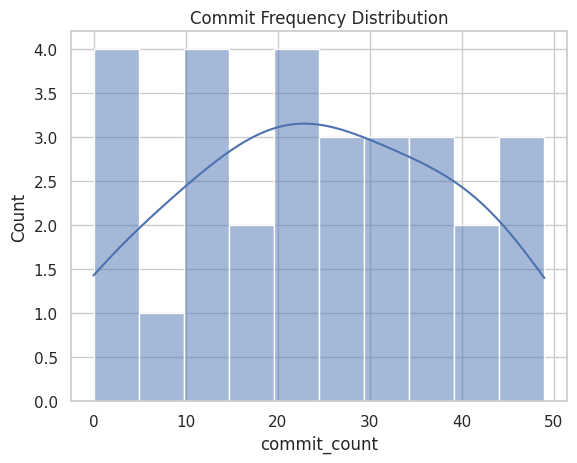

Plot saved to graficos/commit-frequency.png


In [59]:
# In[11]

# Suppose we've added df_members['commit_count'] from some data source
# Just a placeholder example:
if 'commit_count' not in df_members.columns:
    df_members['commit_count'] = np.random.randint(0, 50, len(df_members))

fig, ax = plt.subplots()
sns.histplot(data=df_members, x='commit_count', bins=10, kde=True)
plt.title('Commit Frequency Distribution')
plt.show()
save_plot(fig, 'commit-frequency.png')


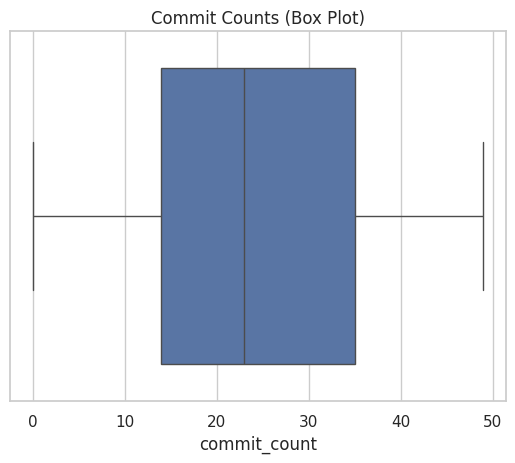

Plot saved to graficos/commit-boxplot.png


,repo,sha,author,message,created_at
0,python-services,88509b5afd7edcc92c55b0b691f366a6a0b04a86,polyanacunha,refactor(send-link): Token insertion correctly...,2024-12-08T06:38:39Z
1,python-services,1601fcef7188a3dcd8fb7b80bb8e557e216e68cf,danrleypereira,fix: validate authentication endpoint (#28)\n\...,2024-12-08T04:28:15Z
2,python-services,cb6c5803c71e9238b3796946f217ec4b511cae58,josue-oliveiraa,Merge pull request #25 from LabTechUDF/refacto...,2024-12-03T23:48:46Z
3,python-services,d29b9ebbca9a8f5907ac0d8ffa2e347eade4f155,josue-oliveiraa,Merge branch 'main' into refactor/arquitetura-...,2024-12-03T23:47:56Z
4,python-services,9707b32dc1c4ba0fa54be7e7d48ebbcbef0ba5b4,josue-oliveiraa,Realocação do método de craição do Hash para a...,2024-11-17T22:31:42Z
...,...,...,...,...,...
255,research,9aea209c3389e80b86e298d6f37c36f85feaed1b,danrleypereira,vamos fazer pesquisa,2024-10-14T21:27:10Z
256,shared-resources,773a1a4d25a00cbef1e66ff8cb639b97c48dccb3,GuiMcs00,GraphQL & RestAPI - Client (#5)\n\n* feat(mode...,2024-12-19T01:35:21Z
257,shared-resources,dd59658ec96bc72ca8722a386f14d38a945f80e0,GuiMcs00,chore: organizando módulos,2024-10-18T23:39:58Z
258,shared-resources,6648360866f0c91cd57e18702db64ac30047e78a,GuiMcs00,feat(x-api_key): Incluindo a verificacao de ap...,2024-10-18T23:36:29Z


In [60]:
# In[12]

fig, ax = plt.subplots()
sns.boxplot(x=df_members['commit_count'])
plt.title('Commit Counts (Box Plot)')
plt.show()
save_plot(fig, 'commit-boxplot.png')

display(df_commits)


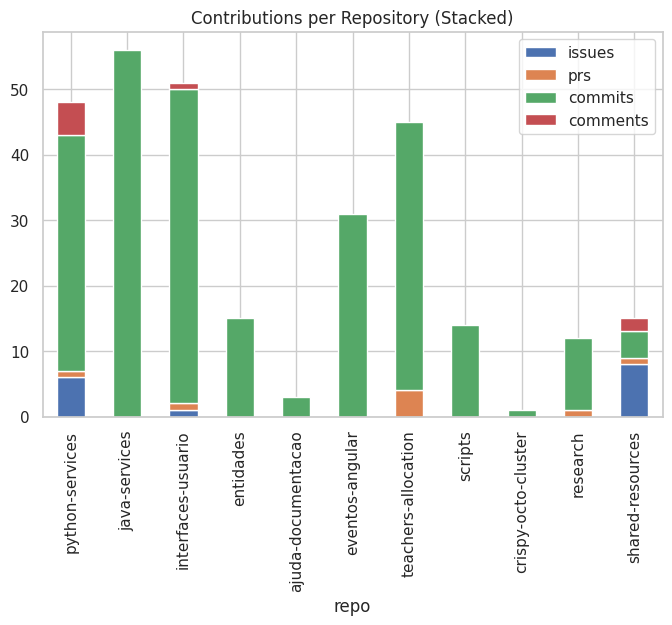

Plot saved to graficos/contributions-per-repo.png


In [61]:
# In[13]
# Build repo_stats list from issues_by_repo
repo_stats_list = []
for r, issues_list in issues_by_repo.items():
    total_issues = sum(1 for i in issues_list if i['pull_request'] is None)
    total_prs = sum(1 for i in issues_list if i['pull_request'] is not None)
    repo_stats_list.append({
        'repo': r,
        'issues': total_issues,
        'prs': total_prs,
        'commits': len(commits_by_repo.get(r, [])),
        'comments': len(df_timeline[(df_timeline['repo'] == r) & (df_timeline['event'] == 'commented')])
    })

# # Convert the list to a DataFrame
df_repo_stats = pd.DataFrame(repo_stats_list)

# Plot issues and PRs (stacked bar) per repository
ax = df_repo_stats.set_index('repo')[['issues', 'prs', 'commits', 'comments']].plot(
    kind='bar', stacked=True, figsize=(8,5),
    title='Contributions per Repository (Stacked)'
)
fig = ax.get_figure()
plt.show()
save_plot(fig, 'contributions-per-repo.png')


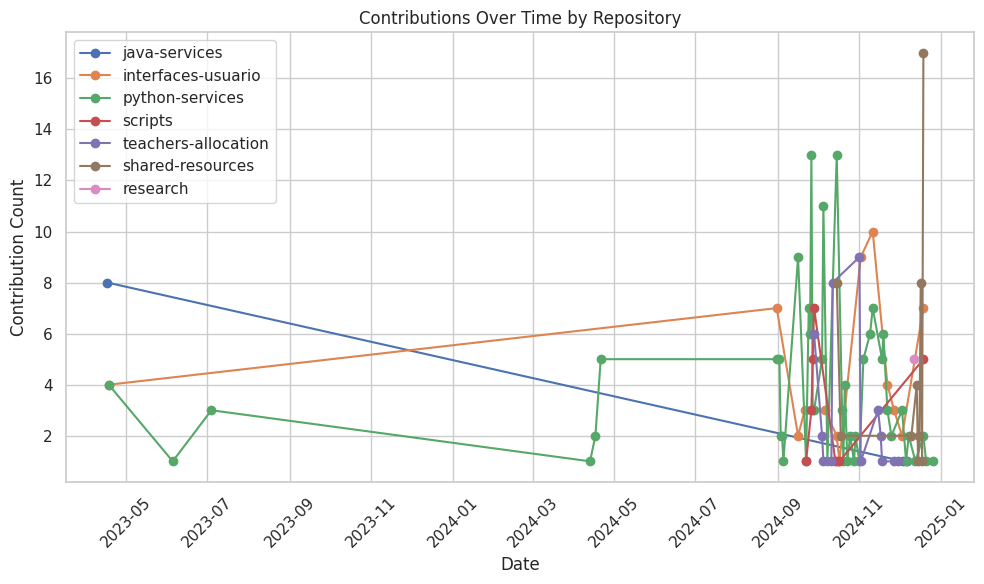

Plot saved to graficos/contributions-over-time.png


In [62]:
# In[14]
all_issue_events = []
# Process issues from issues_by_repo
for r, issues_list in issues_by_repo.items():
    for issue in issues_list:
        created_date = datetime.strptime(issue['created_at'], '%Y-%m-%dT%H:%M:%SZ')
        all_issue_events.append({
            'repo': r,
            'created_at': created_date,
            'type': 'pr' if issue['pull_request'] is not None else 'issue'
        })

# Process events from issues_events_by_repo (ensure proper nesting if needed)
for r, events_list in issues_events_by_repo.items():
    for event in events_list:
        created_date = datetime.strptime(event['created_at'], '%Y-%m-%dT%H:%M:%SZ')
        if event['event'] == 'reviewed':
            event_type = 'pr'
        elif event['event'] == 'committed':
            event_type = 'commit'
        elif event['event'] == 'commented':
            event_type = 'comment'
        else:
            event_type = 'other'
        all_issue_events.append({
            'repo': r,
            'created_at': created_date,
            'type': event_type
        })

# Create the DataFrame and extract the date part
df_all_issues = pd.DataFrame(all_issue_events)
# Create a new column 'date' as datetime objects (without time)
df_all_issues['date'] = pd.to_datetime(df_all_issues['created_at'].dt.date)

# Group by date and repo to get daily counts
daily_counts = df_all_issues.groupby(['date','repo'])['type'].count().reset_index(name='count')

# Plotting
fig, ax = plt.subplots(figsize=(10, 6))
for repo_name in daily_counts['repo'].unique():
    subset = daily_counts[daily_counts['repo'] == repo_name].sort_values('date')
    ax.plot(subset['date'], subset['count'], marker='o', label=repo_name)

ax.set_title('Contributions Over Time by Repository')
ax.set_xlabel('Date')
ax.set_ylabel('Contribution Count')
ax.legend()
ax.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
save_plot(fig, 'contributions-over-time.png')


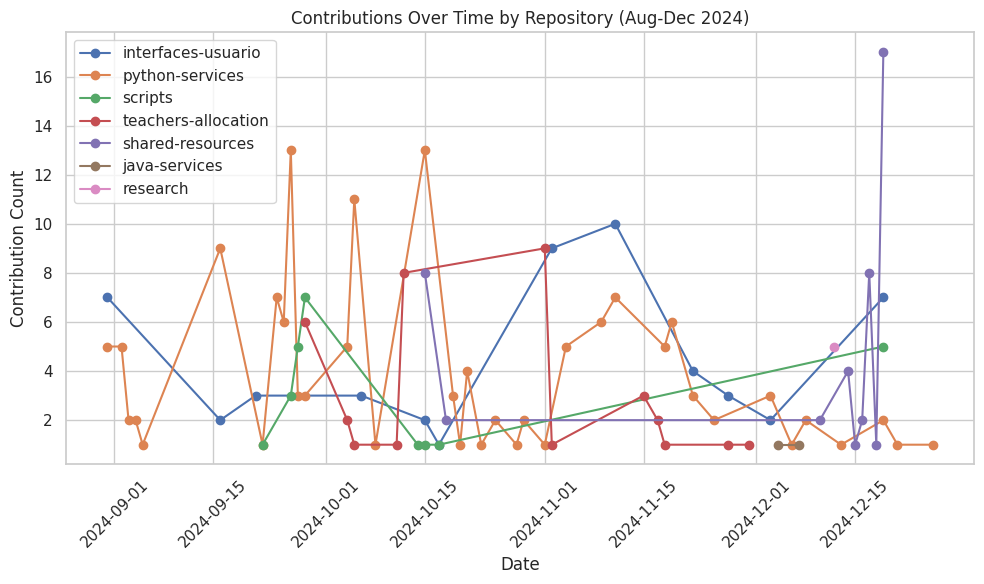

Plot saved to graficos/contributions-over-time-filtered.png


In [63]:
# In[14.4]

# Filter for dates between 2024-08-01 and 2024-12-31
start_date = pd.to_datetime("2024-08-01")
end_date = pd.to_datetime("2024-12-31")
daily_counts_filtered = daily_counts[(daily_counts['date'] >= start_date) & (daily_counts['date'] <= end_date)]

# Plotting the filtered data
fig, ax = plt.subplots(figsize=(10, 6))
for repo_name in daily_counts_filtered['repo'].unique():
    subset = daily_counts_filtered[daily_counts_filtered['repo'] == repo_name].sort_values('date')
    ax.plot(subset['date'], subset['count'], marker='o', label=repo_name)

ax.set_title('Contributions Over Time by Repository (Aug-Dec 2024)')
ax.set_xlabel('Date')
ax.set_ylabel('Contribution Count')
ax.legend()
ax.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
save_plot(fig, 'contributions-over-time-filtered.png')


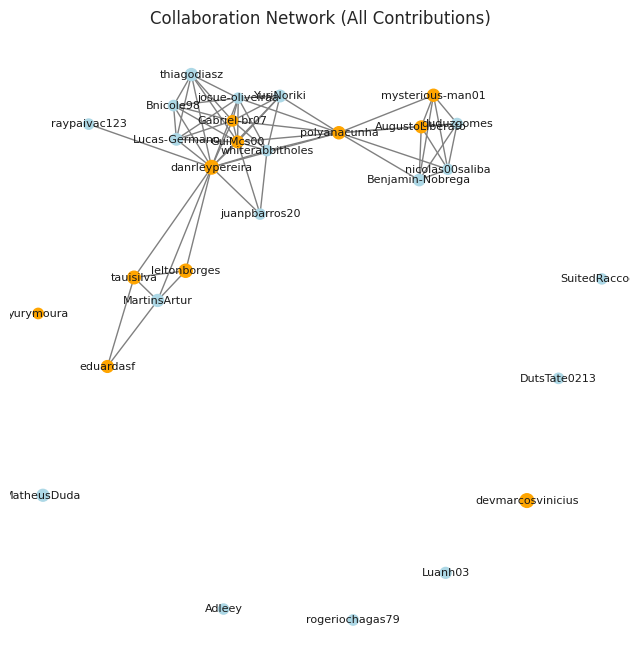

Plot saved to graficos/collaboration-network.png


In [64]:
import networkx as nx
import matplotlib.pyplot as plt

G = nx.Graph()

# Add nodes for each member (assuming df_members has all members)
for m in df_members['login']:
    G.add_node(m)

# Process contributions from all sources per repository
all_repos = set(list(issues_by_repo.keys()) + 
                list(commits_by_repo.keys()) + 
                list(issues_events_by_repo.keys()))

for repo in all_repos:
    contributors = set()
    
    # Issues & PRs contributions
    if repo in issues_by_repo:
        for issue in issues_by_repo[repo]:
            # Use the 'user' key to get the contributor's login
            if issue.get('user') and issue['user'].get('login'):
                contributors.add(issue['user']['login'])
    
    # Commit contributions
    if repo in commits_by_repo:
        for commit in commits_by_repo[repo]:
            # Use the commit 'author' information
            if commit.get('author') and commit['author'].get('login'):
                contributors.add(commit['author']['login'])
    
    # Issue events contributions (comments, reviews, etc.)
    if repo in issues_events_by_repo:
        for event in issues_events_by_repo[repo]:
            # Some events may have 'actor' or 'user'
            if event.get('actor') and event['actor'].get('login'):
                contributors.add(event['actor']['login'])
            elif event.get('user') and event['user'].get('login'):
                contributors.add(event['user']['login'])
    
    # Add edges among all contributors in this repository
    c_list = list(contributors)
    for i in range(len(c_list)):
        for j in range(i + 1, len(c_list)):
            u, v = c_list[i], c_list[j]
            if G.has_edge(u, v):
                G[u][v]['weight'] += 1
            else:
                G.add_edge(u, v, weight=1)

# Compute positions for the layout
pos = nx.spring_layout(G, k=0.5, iterations=50)

# Configure node sizes and colors based on df_members info
node_sizes = []
node_colors = []
for node in G.nodes():
    row = df_members[df_members['login'] == node]
    if not row.empty:
        # Adjust the node size and color based on member maturity and status
        node_sizes.append(row['maturity_score'].values[0]*0.5 + 50)
        node_colors.append('lightblue' if row['status'].values[0] == 'new' else 'orange')
    else:
        node_sizes.append(50)
        node_colors.append('gray')

# Draw the network
fig = plt.figure(figsize=(8,8))
nx.draw_networkx(
    G, pos,
    node_color=node_colors,
    node_size=node_sizes,
    edge_color='gray',
    with_labels=True,
    font_size=8
)
plt.title('Collaboration Network (All Contributions)')
plt.axis('off')
plt.show()
save_plot(fig, 'collaboration-network.png')


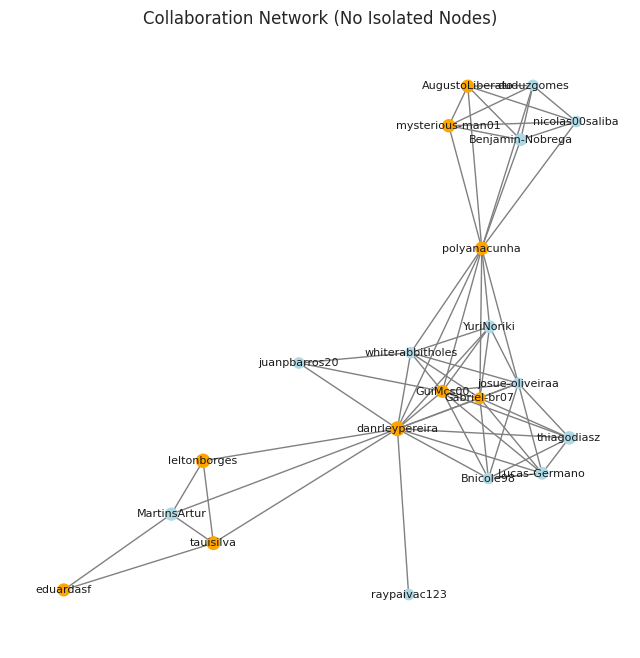

Plot saved to graficos/collaboration-network-no-isolated.png


In [65]:
# In[15.5]
# Remove isolated nodes (nodes with no edges)
isolated_nodes = list(nx.isolates(G))
G.remove_nodes_from(isolated_nodes)

# Recompute layout after removal
pos = nx.spring_layout(G, k=0.5, iterations=50)

# Recompute node sizes and colors for the updated graph
node_sizes = []
node_colors = []
for node in G.nodes():
    row = df_members[df_members['login'] == node]
    if not row.empty:
        node_sizes.append(row['maturity_score'].values[0]*0.5 + 50)
        node_colors.append('lightblue' if row['status'].values[0] == 'new' else 'orange')
    else:
        node_sizes.append(50)
        node_colors.append('gray')

fig = plt.figure(figsize=(8,8))
nx.draw_networkx(
    G, pos,
    node_color=node_colors,
    node_size=node_sizes,
    edge_color='gray',
    with_labels=True,
    font_size=8
)
plt.title('Collaboration Network (No Isolated Nodes)')
plt.axis('off')
plt.show()
save_plot(fig, 'collaboration-network-no-isolated.png')


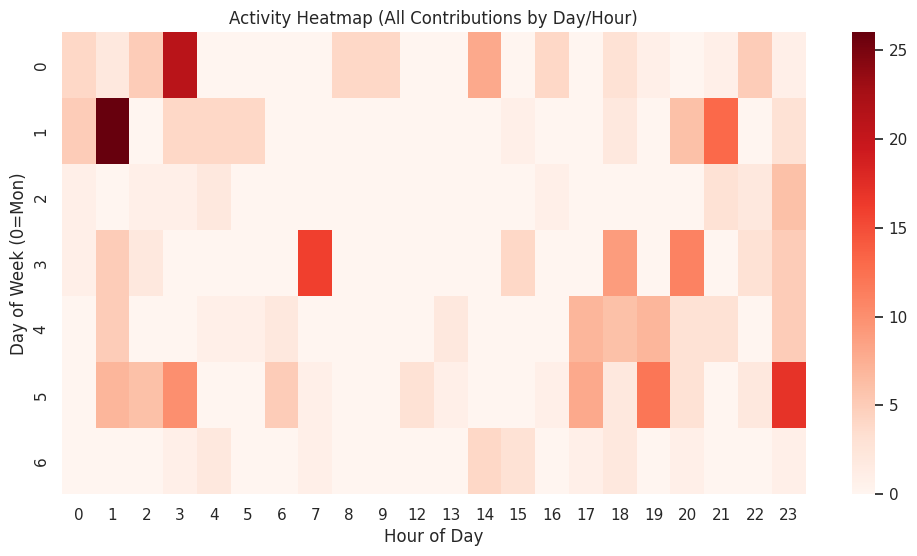

Plot saved to graficos/activity-heatmap.png


In [66]:
# In[16]

# Make sure df_all_issues has all contributions loaded
df_all_issues['day_of_week'] = df_all_issues['created_at'].dt.dayofweek  # Monday=0, Sunday=6
df_all_issues['hour_of_day'] = df_all_issues['created_at'].dt.hour

# Group by day of week and hour of day
heatmap_data = df_all_issues.groupby(['day_of_week', 'hour_of_day']).size().reset_index(name='count')
heatmap_pivot = heatmap_data.pivot(index='day_of_week', columns='hour_of_day', values='count').fillna(0)

fig = plt.figure(figsize=(12,6))
sns.heatmap(heatmap_pivot, cmap='Reds', annot=False, fmt='.0f')
plt.title('Activity Heatmap (All Contributions by Day/Hour)')
plt.ylabel('Day of Week (0=Mon)')
plt.xlabel('Hour of Day')
plt.show()
save_plot(fig, 'activity-heatmap.png')



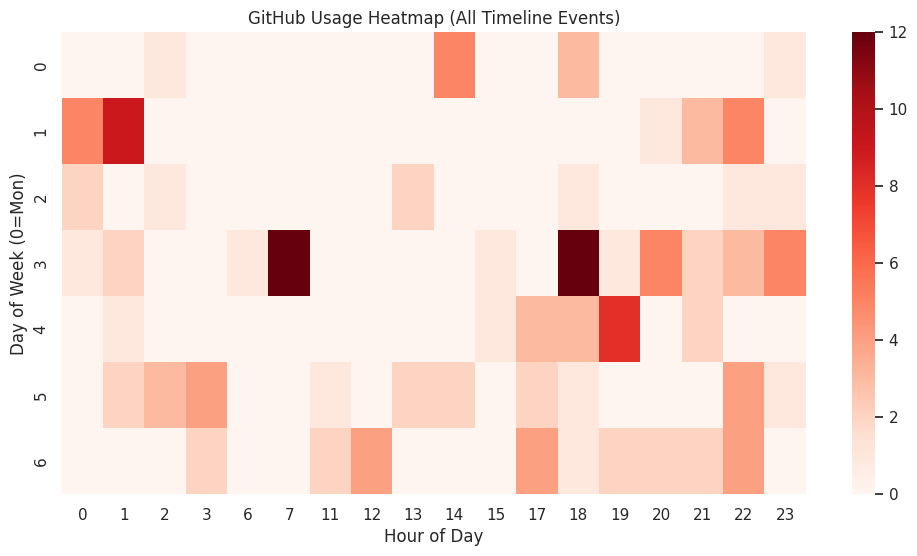

Plot saved to graficos/github-usage-heatmap.png


In [67]:
# In[16.2]
# Convert 'created_at' to datetime
df_timeline['created_at'] = pd.to_datetime(df_timeline['created_at'], format='%Y-%m-%dT%H:%M:%SZ')

# Extract day of week and hour from created_at
df_timeline['day_of_week'] = df_timeline['created_at'].dt.dayofweek  # Monday=0, Sunday=6
df_timeline['hour_of_day'] = df_timeline['created_at'].dt.hour

# Group by day of week and hour to count events
heatmap_data = df_timeline.groupby(['day_of_week', 'hour_of_day']).size().reset_index(name='count')
heatmap_pivot = heatmap_data.pivot(index='day_of_week', columns='hour_of_day', values='count').fillna(0)

# Plot heatmap
fig = plt.figure(figsize=(12,6))
sns.heatmap(heatmap_pivot, cmap='Reds', annot=False, fmt='g')
plt.title('GitHub Usage Heatmap (All Timeline Events)')
plt.ylabel('Day of Week (0=Mon)')
plt.xlabel('Hour of Day')
plt.show()
save_plot(fig, 'github-usage-heatmap.png')

,repo,state,created_at,updated_at
0,python-services,opened,2024-12-21 01:14:40,2024-12-21 01:14:40
1,python-services,opened,2024-12-19 18:08:57,2024-12-19 18:08:57
2,python-services,opened,2024-11-22 17:25:04,2024-12-04 20:02:40
3,python-services,opened,2024-11-04 14:56:30,2024-12-26 01:14:40
4,python-services,opened,2024-10-29 00:28:15,2024-12-12 18:28:49


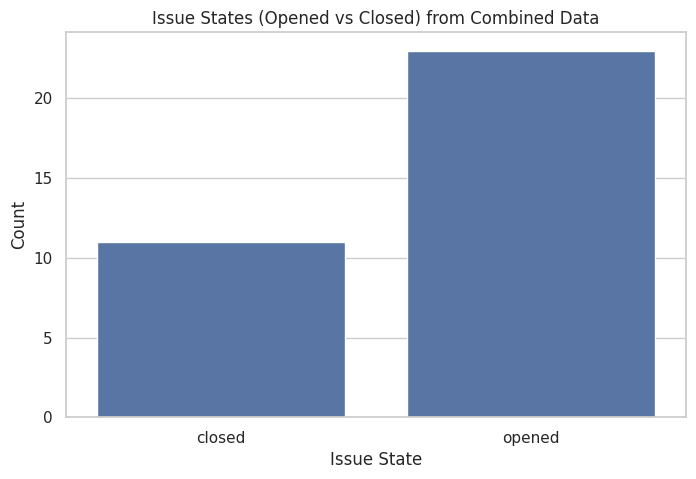

Plot saved to graficos/issue-states.png


In [68]:
# In[17]

# Aggregate "opened" events from issues_by_repo (issue creation represents an open event)
all_open_events = []
for repo, issues in issues_by_repo.items():
    for issue in issues:
        all_open_events.append({
            'repo': repo,
            'state': 'opened',  # issue creation implies it's opened
            'created_at': issue.get('created_at'),
            'updated_at': issue.get('updated_at')
        })

# Aggregate "closed" events from issues_events_by_repo
all_closed_events = []
for repo, events in issues_events_by_repo.items():
    for event in events:
        # Look for a closed event type from timeline events
        if event.get("event") == "closed" and event['issue'].get('pull_request') is None:
            all_closed_events.append({
                'repo': repo,
                'state': 'closed',
                'created_at': event.get('created_at'),
                # Try to get updated_at from the event; if missing, check the embedded issue
                'updated_at': event.get('updated_at') or (event.get('issue') and event.get('issue').get('updated_at'))
            })

# Combine the opened and closed events into one list
all_opened_closed_events = all_open_events + all_closed_events

# Build a DataFrame from the aggregated data
df_issues_states = pd.DataFrame(all_opened_closed_events)

# Convert the timestamp fields to datetime objects
df_issues_states['created_at'] = pd.to_datetime(df_issues_states['created_at'], format='%Y-%m-%dT%H:%M:%SZ', errors='coerce')
df_issues_states['updated_at'] = pd.to_datetime(df_issues_states['updated_at'], format='%Y-%m-%dT%H:%M:%SZ', errors='coerce')

display(df_issues_states.head())

# Aggregate counts by state
summary_df = df_issues_states.groupby("state").size().reset_index(name="count")

# Plot the bar plot using Seaborn
fig = plt.figure(figsize=(8,5))
sns.barplot(data=summary_df, x="state", y="count")
plt.title('Issue States (Opened vs Closed) from Combined Data')
plt.xlabel('Issue State')
plt.ylabel('Count')
plt.show()
save_plot(fig, 'issue-states.png')





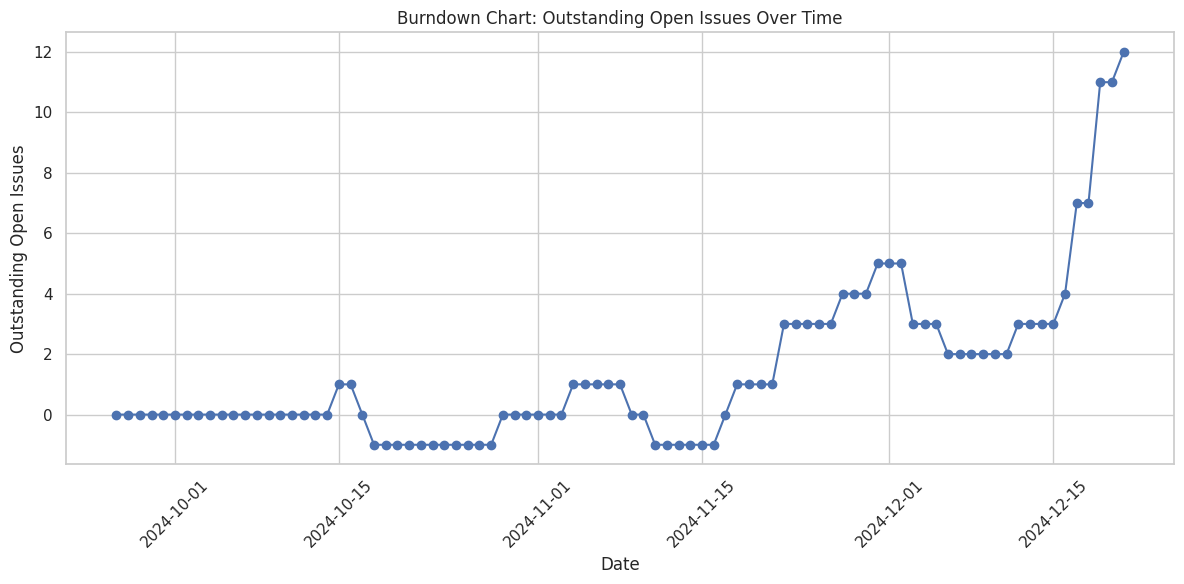

Plot saved to graficos/burndown-chart.png


In [69]:
# In[18]
# Create a copy of the issues states DataFrame for burndown analysis
df_burndown = df_issues_states.copy()

# Add a delta: +1 for an opened event, -1 for a closed event
df_burndown['delta'] = df_burndown['state'].apply(lambda x: 1 if x=='opened' else -1)

# Use the created_at timestamp as the event date
df_burndown['date'] = df_burndown['created_at'].dt.date

# Group by date to sum up the deltas (net change per day)
daily_delta = df_burndown.groupby('date')['delta'].sum().reset_index()

# Create a complete date range from the first to the last event
start_date = daily_delta['date'].min()
end_date = daily_delta['date'].max()
all_dates = pd.date_range(start=start_date, end=end_date, freq='D')

# Reindex daily_delta to have an entry for every day, filling missing days with 0 change
daily_delta = daily_delta.set_index('date').reindex(all_dates, fill_value=0)
daily_delta.index.name = 'date'
daily_delta = daily_delta.reset_index()

# Compute the cumulative sum of daily deltas to get outstanding open issues over time
daily_delta['cum_open'] = daily_delta['delta'].cumsum()

# Plot the burndown chart
fig = plt.figure(figsize=(12,6))
plt.plot(daily_delta['date'], daily_delta['cum_open'], marker='o', linestyle='-')
plt.title('Burndown Chart: Outstanding Open Issues Over Time')
plt.xlabel('Date')
plt.ylabel('Outstanding Open Issues')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
save_plot(fig, 'burndown-chart.png')


,repo,issue_number,issue_created_at,issue_closed_at,cycle_time_days
0,python-services,26,2024-11-22 04:00:40,2024-12-06 13:06:38,14.379144
1,python-services,20,2024-10-15 01:21:42,2024-12-03 23:48:47,49.935475
2,python-services,19,2024-10-05 03:58:31,2024-11-09 19:33:38,35.649387
3,python-services,14,2024-09-28 23:30:44,2024-10-15 01:03:12,16.064213
4,python-services,9,2024-09-22 07:57:20,2024-09-26 20:30:58,4.523356


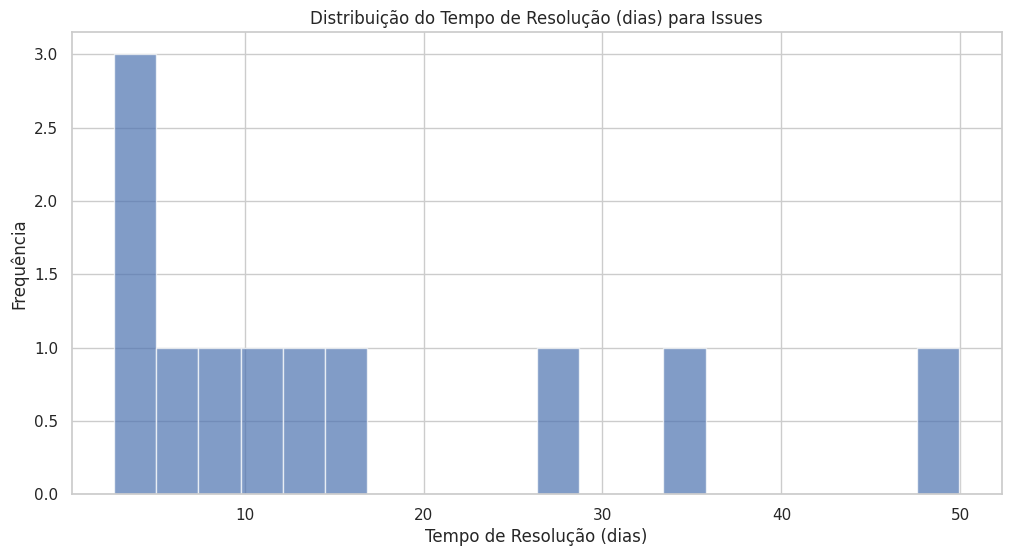

Plot saved to graficos/cycle-time-histogram.png


In [70]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. DataFrame com os eventos de issues (já disponível)
# Supondo que você já criou o df_issue_events:
# all_issue_events = []
# for repo_name, events_list in issues_events_by_repo.items():
#     for event in events_list:
#         event_dict = {
#             'repo': repo_name,
#             'issue_number': event['issue']['number'],
#             'actor': event['actor']['login'],
#             'event': event['event'],
#             'created_at': event['created_at'],
#         }
#         all_issue_events.append(event_dict)
# df_issue_events = pd.DataFrame(all_issue_events)

# 2. Filtrar os eventos de fechamento (closed) do df_issue_events
df_closed_events = df_issue_events[df_issue_events['event'] == 'closed'].copy()

# Converter o timestamp do evento em datetime
df_closed_events['event_created_at'] = pd.to_datetime(
    df_closed_events['created_at'], format='%Y-%m-%dT%H:%M:%SZ', errors='coerce'
)

# 3. Extrair a data de criação e fechamento a partir da issue interna presente no evento
# Supondo que cada evento de fechamento tenha a estrutura 'issue' com os campos 'created_at' e 'closed_at'
# Primeiro, criamos listas para armazenar os dados extraídos
cycle_data = []
for repo, events in issues_events_by_repo.items():
    for event in events:
        if event.get("event") == "closed":
            issue_info = event.get("issue", {})
            if not issue_info.get("pull_request"):
                created_at_str = issue_info.get("created_at")
                closed_at_str = issue_info.get("closed_at")
                if created_at_str and closed_at_str:
                    issue_created_at = pd.to_datetime(created_at_str, format='%Y-%m-%dT%H:%M:%SZ', errors='coerce')
                    issue_closed_at = pd.to_datetime(closed_at_str, format='%Y-%m-%dT%H:%M:%SZ', errors='coerce')
                    if pd.notnull(issue_created_at) and pd.notnull(issue_closed_at):
                        cycle_data.append({
                            'repo': repo,
                            'issue_number': issue_info.get("number"),
                            'issue_created_at': issue_created_at,
                            'issue_closed_at': issue_closed_at,
                            'cycle_time_days': (issue_closed_at - issue_created_at).total_seconds() / (3600 * 24)
                        })

# Cria o DataFrame dos tempos de ciclo
df_cycle = pd.DataFrame(cycle_data)
display(df_cycle.head())

# 4. Plotar um histograma do tempo de resolução (cycle time) em dias
fig = plt.figure(figsize=(12,6))
plt.hist(df_cycle['cycle_time_days'].dropna(), bins=20, alpha=0.7)
plt.title('Distribuição do Tempo de Resolução (dias) para Issues')
plt.xlabel('Tempo de Resolução (dias)')
plt.ylabel('Frequência')
plt.show()
save_plot(fig, 'cycle-time-histogram.png')


,repo,pr_number,pr_created_at,pr_closed_at,cycle_time_days
0,python-services,28,2024-11-25 03:04:29,2024-12-08 04:28:15,13.058171
1,python-services,25,2024-11-18 03:06:32,2024-12-03 23:48:47,15.862674
2,python-services,24,2024-11-11 01:37:54,2024-11-11 02:44:24,0.046181
3,python-services,21,2024-10-19 02:51:05,2024-11-09 19:33:37,21.696204
4,python-services,18,2024-10-05 02:33:43,2024-10-15 01:03:11,9.937130


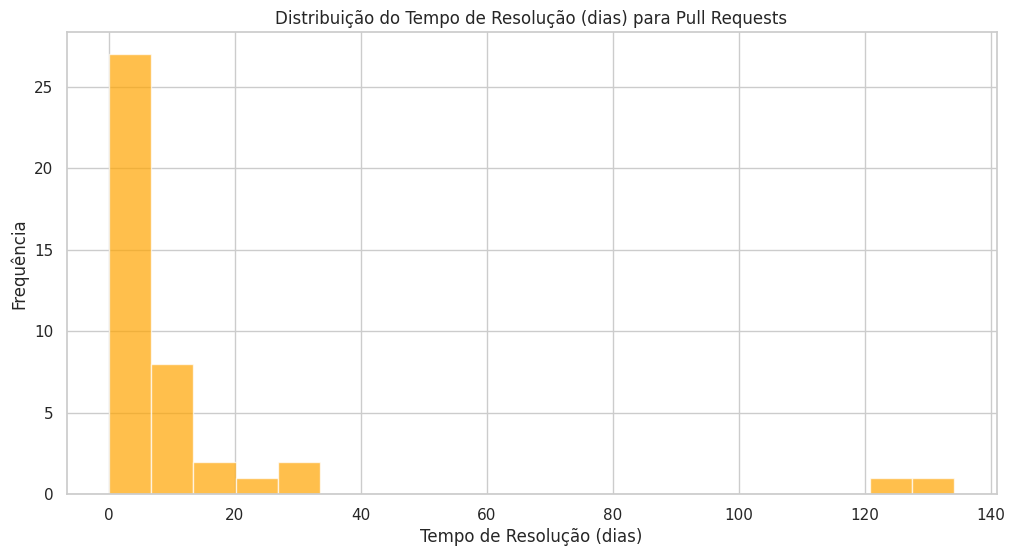

Plot saved to graficos/pr-cycle-time-histogram.png


In [71]:
# 1. Filtrar os eventos de fechamento (closed) que correspondem a pull requests a partir de issues_events_by_repo
pr_cycle_data = []
for repo, events in issues_events_by_repo.items():
    for event in events:
        if event.get("event") == "closed":
            issue_info = event.get("issue", {})
            # Para pull requests, o campo "pull_request" deve existir e não ser None
            if issue_info.get("pull_request") is not None:
                created_at_str = issue_info.get("created_at")
                closed_at_str = issue_info.get("closed_at")
                if created_at_str and closed_at_str:
                    pr_created_at = pd.to_datetime(created_at_str, format='%Y-%m-%dT%H:%M:%SZ', errors='coerce')
                    pr_closed_at = pd.to_datetime(closed_at_str, format='%Y-%m-%dT%H:%M:%SZ', errors='coerce')
                    if pd.notnull(pr_created_at) and pd.notnull(pr_closed_at):
                        pr_cycle_data.append({
                            'repo': repo,
                            'pr_number': issue_info.get("number"),
                            'pr_created_at': pr_created_at,
                            'pr_closed_at': pr_closed_at,
                            'cycle_time_days': (pr_closed_at - pr_created_at).total_seconds() / (3600 * 24)
                        })

# Cria o DataFrame dos tempos de ciclo para pull requests
df_pr_cycle = pd.DataFrame(pr_cycle_data)
display(df_pr_cycle.head())

# 2. Plotar um histograma do tempo de resolução (cycle time) em dias para pull requests
fig = plt.figure(figsize=(12,6))
plt.hist(df_pr_cycle['cycle_time_days'].dropna(), bins=20, alpha=0.7, color='orange')
plt.title('Distribuição do Tempo de Resolução (dias) para Pull Requests')
plt.xlabel('Tempo de Resolução (dias)')
plt.ylabel('Frequência')
plt.show()
save_plot(fig, 'pr-cycle-time-histogram.png')


,member,repo_count
0,GuiMcs00,6
1,danrleypereira,9
2,Gabriel-br07,4
3,mysterious-man01,1
4,nicolas00saliba,1


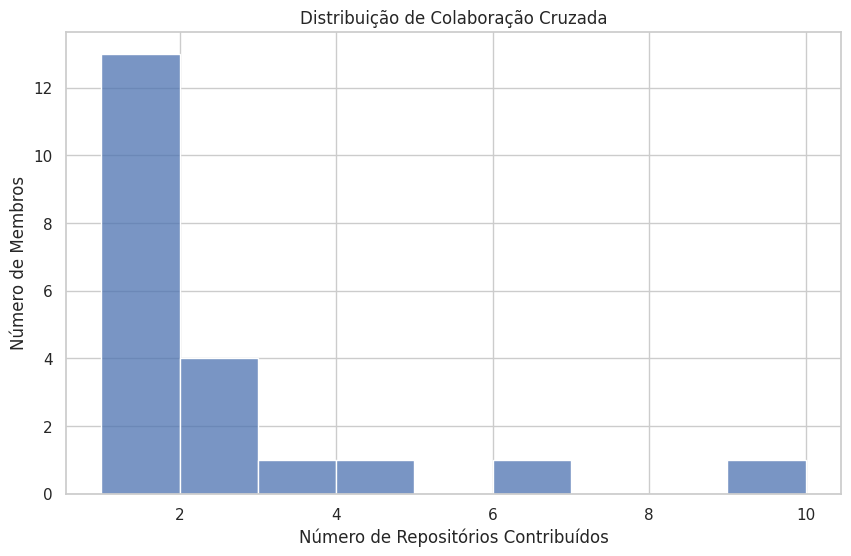

Plot saved to graficos/cross-collab-histogram.png
Membros atuando em múltiplos repositórios (hubs):
              member  repo_count
1     danrleypereira           9
0           GuiMcs00           6
2       Gabriel-br07           4
15  whiterabbitholes           3
6       polyanacunha           2
7    josue-oliveiraa           2
9          tauisilva           2
10      MartinsArtur           2


In [72]:

# Dicionário para armazenar os repositórios em que cada membro contribuiu
member_repos = {}

# Contribuições via issues (ou PRs) – extraindo o login do usuário
for repo, issues in issues_by_repo.items():
    for issue in issues:
        user = issue.get("user", {}).get("login")
        if user:
            member_repos.setdefault(user, set()).add(repo)
            
# Contribuições via commits
for repo, commits in commits_by_repo.items():
    for commit in commits:
        author = commit.get("author")
        if author:
            user = author.get("login")
            if user:
                member_repos.setdefault(user, set()).add(repo)
            
# Contribuições via eventos (issues_events)
for repo, events in issues_events_by_repo.items():
    for event in events:
        actor = event.get("actor")
        user = actor.get("login") if actor else event.get("user", {}).get("login")
        if user:
            member_repos.setdefault(user, set()).add(repo)

# Cria um DataFrame com o número de repositórios por membro
cross_collab = [{"member": member, "repo_count": len(repos)} for member, repos in member_repos.items()]
df_cross = pd.DataFrame(cross_collab)
display(df_cross.head())

# Plot: Histograma do número de repositórios em que cada membro contribuiu
fig = plt.figure(figsize=(10,6))
sns.histplot(df_cross["repo_count"], bins=range(1, df_cross["repo_count"].max()+2), kde=False)
plt.title("Distribuição de Colaboração Cruzada")
plt.xlabel("Número de Repositórios Contribuídos")
plt.ylabel("Número de Membros")
plt.show()
save_plot(fig, 'cross-collab-histogram.png')

# Identificar hubs: membros que contribuíram em mais de 1 repositório
hubs = df_cross[df_cross["repo_count"] > 1]
print("Membros atuando em múltiplos repositórios (hubs):")
print(hubs.sort_values("repo_count", ascending=False))


In [73]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# Exemplo: DataFrame com contagem diária de commits
# df_commits_daily deve ter um índice datetime e uma coluna 'commit_count'
# Exemplo de criação fictícia:
# dates = pd.date_range(start='2024-01-01', end='2024-12-31', freq='D')
# df_commits_daily = pd.DataFrame({'commit_count': np.random.poisson(5, len(dates))}, index=dates)

# Definir os parâmetros do modelo SARIMA:
# order=(p,d,q) para a parte não sazonal
# seasonal_order=(P,D,Q,s) para a parte sazonal, onde s é o período (por exemplo, 7 para dias da semana)
p, d, q = 1, 1, 1          # ajuste conforme seus dados
P, D, Q, s = 1, 1, 1, 7     # sazonalidade semanal (s=7)

# Ajustar o modelo SARIMA
model = SARIMAX(df_commits_daily['commit_count'], order=(p, d, q), 
                seasonal_order=(P, D, Q, s), 
                enforce_stationarity=False, enforce_invertibility=False)
model_fit = model.fit(disp=False)

# Fazer previsões para os próximos 30 dias (ou ajuste o período desejado)
forecast = model_fit.get_forecast(steps=30)
forecast_ci = forecast.conf_int()

# Plotar os dados observados e a previsão
plt.figure(figsize=(12,6))
plt.plot(df_commits_daily.index, df_commits_daily['commit_count'], label="Observado")
plt.plot(forecast.predicted_mean.index, forecast.predicted_mean, color='red', label="Previsão")
plt.fill_between(forecast_ci.index,
                 forecast_ci.iloc[:, 0],
                 forecast_ci.iloc[:, 1], color='pink', alpha=0.3)
plt.xlabel('Data')
plt.ylabel('Número de Commits')
plt.title('Previsão de Commits com SARIMA')
plt.legend()
plt.show()
save_plot(plt, 'sarima-forecast.png')


ModuleNotFoundError: No module named 'statsmodels'